# Demonstration of MUSE

This is a demonstration of MUSE analysis on a multi-modality simulated data.

Feng Bao @ Altschuler & Wu Lab @ UCSF 2022.

Software provided as is under MIT License.

## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# import tensorflow as tf
# import os
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# tf.get_logger().setLevel('ERROR')
np.random.seed(0)

## Generate simulation data


Simulation parameters

In [2]:
latent_dim = 100
num_cluster = 10
sample_size = 1000
latent_code_dim = 30
observed_data_dim = 500
sigma_1 = 0.1  
sigma_2 = 0.1
decay_coef_1 = 0.5 
decay_coef_2 = 0.1
merge_prob = 0.7



Use simulation tool to generate multi-modality data

In [3]:
data = simulation.multi_modal_simulator(
    num_cluster,
    sample_size,
    observed_data_dim,
    observed_data_dim,
    latent_code_dim,
    sigma_1,
    sigma_2,
    decay_coef_1,
    decay_coef_2,
    merge_prob,
)
data_a = data["data_a_dropout"]
data_b = data["data_b_dropout"]
label_a = data["data_a_label"]
label_b = data["data_b_label"]
label_true = data["true_cluster"]

## Analyses based on single modality

Learn features from single modality

In [4]:
view_a_feature = PCA(n_components=latent_dim).fit_transform(data_a)
view_b_feature = PCA(n_components=latent_dim).fit_transform(data_b)

In [5]:
print(f"data_a shape: {data_a.shape}")
print(f"data_b shape: {data_b.shape}")
print(f"view_a_feature shape: {view_a_feature.shape}")
print(f"view_b_feature shape: {view_b_feature.shape}")

data_a shape: (1000, 500)
data_b shape: (1000, 500)
view_a_feature shape: (1000, 100)
view_b_feature shape: (1000, 100)


Perform clustering using PhenoGraph

In [6]:
view_a_label, _, _ = phenograph.cluster(view_a_feature)
view_b_label, _, _ = phenograph.cluster(view_b_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.09432530403137207 seconds
Jaccard graph constructed in 0.16890692710876465 seconds
Wrote graph to binary file in 0.00548553466796875 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.550249
Louvain completed 21 runs in 0.38407206535339355 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.7715795040130615 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06876659393310547 seconds
Jaccard graph constructed in 0.1565840244293213 seconds
Wrote graph to binary file in 0.0049059391021728516 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.61777
Louvain completed 21 runs in 0.387984037399292 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.7402174472808838 seconds


## Combined analysis using MUSE

MUSE learns the joint latent representation

In [7]:
muse_feature, reconstruct_x, reconstruct_y, latent_x, latent_y = muse.muse_fit_predict(
    data_a,
    data_b,
    view_a_label,
    view_b_label,
    latent_dim=100,
    n_epochs=500,
    weight_penalty=5,
    triplet_lambda=5,
)

++++++++++ MUSE for multi-modality single-cell analysis ++++++++++
epoch: 0, 	 total loss: 706.63458,	 reconstruction loss: 12.35168,	 sparse penalty: 138.85658
epoch: 50, 	 total loss: 657.67572,	 reconstruction loss: 4.68649,	 sparse penalty: 130.59785
epoch: 100, 	 total loss: 617.78339,	 reconstruction loss: 4.39084,	 sparse penalty: 122.67851
epoch: 150, 	 total loss: 579.48608,	 reconstruction loss: 4.18464,	 sparse penalty: 115.06029
epoch: 0, 	 total loss: 554.10895,	 reconstruction loss: 4.13408,	 sparse penalty: 107.72607,	 x triplet: 1.19059,	 y triplet: 1.07832
epoch: 50, 	 total loss: 516.04565,	 reconstruction loss: 4.06495,	 sparse penalty: 100.66962,	 x triplet: 0.85710,	 y triplet: 0.86942
epoch: 100, 	 total loss: 481.03613,	 reconstruction loss: 3.99681,	 sparse penalty: 93.88840,	 x triplet: 0.74567,	 y triplet: 0.77379
epoch: 150, 	 total loss: 448.10062,	 reconstruction loss: 3.94371,	 sparse penalty: 87.38322,	 x triplet: 0.70354,	 y triplet: 0.74463
Finding 30 n

## Perform clustering
PhenoGraph clustering

In [8]:
muse_label, _, _ = phenograph.cluster(muse_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0693960189819336 seconds
Jaccard graph constructed in 0.395125150680542 seconds
Wrote graph to binary file in 0.0038232803344726562 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.920261
Louvain completed 21 runs in 0.7459776401519775 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.5492477416992188 seconds


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

view_a_feature: (1000, 100)
X_embedded: (1000, 2)
label_true: (1000,)
laber_true == i: (1000,)
np.nonzero(label_true == i): 94


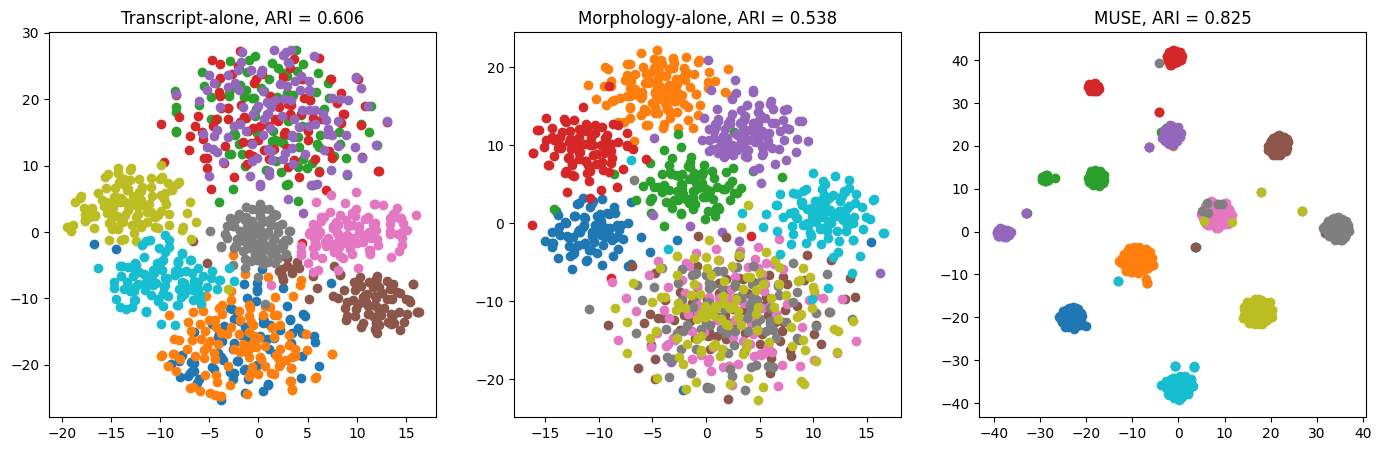

In [9]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 3, 1)
print(f"view_a_feature: {view_a_feature.shape}")
X_embedded = TSNE(n_components=2).fit_transform(view_a_feature)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {label_true.shape}")
print(f"laber_true == i: {(label_true == 0).shape}")
print(f"np.nonzero(label_true == i): {len(np.nonzero(label_true == 2)[0])}")
# 遍历每一个类别
for i in np.unique(label_true):
    # 找到所有类别为i的索引
    idx = np.nonzero(label_true == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Transcript-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_a_label))

plt.subplot(1, 3, 2)
X_embedded = TSNE(n_components=2).fit_transform(view_b_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Morphology-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_b_label))

plt.subplot(1, 3, 3)
X_embedded = TSNE(n_components=2).fit_transform(muse_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, muse_label))